In [1]:
import os

data_path  = "C:/Users/armin/Downloads/Documents/Datasets/Deep Globe/archive"
train_path = data_path + "/train"
valid_path = data_path + "/valid"
test_path  = data_path + "/test"

In [2]:
os.listdir(train_path)[:4]

['100034_mask.png', '100034_sat.jpg', '100081_mask.png', '100081_sat.jpg']

In [3]:
import cv2

test_mask  = cv2.imread(os.path.join(train_path, os.listdir(train_path)[0]))
test_image = cv2.imread(os.path.join(train_path, os.listdir(train_path)[1]))

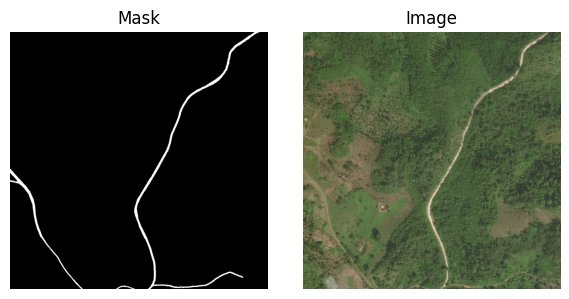

In [4]:
import matplotlib.pyplot as plt

# Convert BGR (OpenCV) to RGB (Matplotlib)
test_mask  = cv2.cvtColor(test_mask, cv2.COLOR_BGR2RGB)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(test_mask)
axes[0].set_title("Mask")
axes[0].axis("off")

axes[1].imshow(test_image)
axes[1].set_title("Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Split train to 80/20
from sklearn.model_selection import train_test_split

files = os.listdir(train_path)

# Extract unique sample IDs
sample_ids = sorted({
    filename.split('_')[0]
    for filename in files
})

print(f"Number of samples: {len(sample_ids)}")

# 80/20 split
train_ids, val_ids = train_test_split(
    sample_ids,
    test_size=0.2,
    random_state=42
)

print(f"Train samples: {len(train_ids)}")
print(f"Validation samples: {len(val_ids)}")


Number of samples: 6226
Train samples: 4980
Validation samples: 1246


In [6]:
train_pairs = []
val_pairs = []

for sample_id in train_ids:
    image_path = os.path.join(train_path, f"{sample_id}_sat.jpg")
    mask_path = os.path.join(train_path, f"{sample_id}_mask.png")
    train_pairs.append((image_path, mask_path))

for sample_id in val_ids:
    image_path = os.path.join(train_path, f"{sample_id}_sat.jpg")
    mask_path = os.path.join(train_path, f"{sample_id}_mask.png")
    val_pairs.append((image_path, mask_path))

In [7]:
len(train_pairs), len(val_pairs)

(4980, 1246)

In [9]:
#model
import torch
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [10]:
import albumentations as A

train_transform = A.Compose([
    A.RandomCrop(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    )
])

val_transform = None

In [11]:
from torch.utils.data import Dataset
import torch
import numpy as np

class RoadDataset(Dataset):
    def __init__(self, pairs, patch_size=256, transform=None):
        self.pairs = pairs
        self.patch_size = patch_size
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask
            )
            image = augmented["image"]
            mask = augmented["mask"]

        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        image = torch.from_numpy(image.transpose(2,0,1))
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [10]:
from torch.utils.data import DataLoader

train_ds = RoadDataset(train_pairs)
val_ds = RoadDataset(val_pairs)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [12]:
# Loss functions

import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)

    pred = pred.reshape(-1)
    target = target.reshape(-1)

    intersection = (pred * target).sum()

    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    return 1 - dice


def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5
)

In [13]:
# metrics

def dice_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()

    smooth = 1e-6
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection + smooth) / (union + smooth)

def iou_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum()
    union = ((pred + target) > 0).float().sum()

    return intersection / (union + 1e-6)

In [14]:
from tqdm import tqdm

def evaluate(model, loader):
    model.eval()

    total_loss = 0
    total_iou = 0
    total_dice = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.cuda()
            masks = masks.cuda()

            preds = model(imgs)

            loss = loss_fn(preds, masks)

            total_loss += loss.item()
            total_iou += iou_score(preds, masks).item()
            total_dice += dice_score(preds, masks).item()

    n = len(loader)

    return {
        "loss": total_loss / n,
        "iou": total_iou / n,
        "dice": total_dice / n
    }

In [ ]:
# training loop unet
num_epochs = 30

scaler = torch.amp.GradScaler('cuda')

for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0
    train_iou = 0.0
    train_dice = 0.0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for imgs, masks in loop:

        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # with torch.amp.autocast('cuda'):

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        # ---- safety check (IMPORTANT) ----
        if torch.isnan(loss):
            print(f"NaN loss detected at batch {n_batches}")
            break

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        # ---- metrics (detach + float-safe) ----
        with torch.no_grad():
            iou = iou_score(preds, masks)
            dice = dice_score(preds, masks)

        train_loss += loss.item()
        train_iou += iou.item()
        train_dice += dice.item()

        n_batches += 1

        loop.set_postfix(loss=loss.item())

    # ---- avoid division by zero ----
    n_batches = max(n_batches, 1)

    train_metrics = {
        "loss": train_loss / n_batches,
        "iou": train_iou / n_batches,
        "dice": train_dice / n_batches,
    }

    val_metrics = evaluate(model, val_loader)

    print(f"""
Epoch {epoch+1}
Train Loss: {train_metrics['loss']:.4f} | IoU: {train_metrics['iou']:.4f} | Dice: {train_metrics['dice']:.4f}
Val   Loss: {val_metrics['loss']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f}
""")

Epoch 1: 100%|██████████| 623/623 [04:16<00:00,  2.43it/s, loss=1.07] 



Epoch 1
Train Loss: 1.2548 | IoU: 0.2119 | Dice: 0.3319
Val   Loss: 1.0157 | IoU: 0.3481 | Dice: 0.5088



Epoch 2: 100%|██████████| 623/623 [03:57<00:00,  2.62it/s, loss=0.849]



Epoch 2
Train Loss: 0.9146 | IoU: 0.3715 | Dice: 0.5316
Val   Loss: 0.8112 | IoU: 0.4284 | Dice: 0.5935



Epoch 3: 100%|██████████| 623/623 [03:56<00:00,  2.63it/s, loss=0.461]


...


Epoch 28
Train Loss: 0.3754 | IoU: 0.5734 | Dice: 0.7219
Val   Loss: 0.3915 | IoU: 0.5601 | Dice: 0.7121



Epoch 29: 100%|██████████| 623/623 [03:40<00:00,  2.83it/s, loss=0.264]



Epoch 29
Train Loss: 0.3655 | IoU: 0.5808 | Dice: 0.7297
Val   Loss: 0.3791 | IoU: 0.5715 | Dice: 0.7208



Epoch 30: 100%|██████████| 623/623 [03:48<00:00,  2.73it/s, loss=0.4]  



Epoch 30
Train Loss: 0.3606 | IoU: 0.5870 | Dice: 0.7345
Val   Loss: 0.4007 | IoU: 0.5492 | Dice: 0.7011



In [16]:
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [174]:
def predict_image(model, image_path):
    model.eval()

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (1024, 1024))

    x = torch.from_numpy(img_resized).float() / 255.0
    x = x.permute(2,0,1).unsqueeze(0).cuda()

    with torch.no_grad():
        pred = torch.sigmoid(model(x))[0,0].cpu().numpy()

    mask = (pred > 0.3).astype(np.float16)

    return img_resized, mask

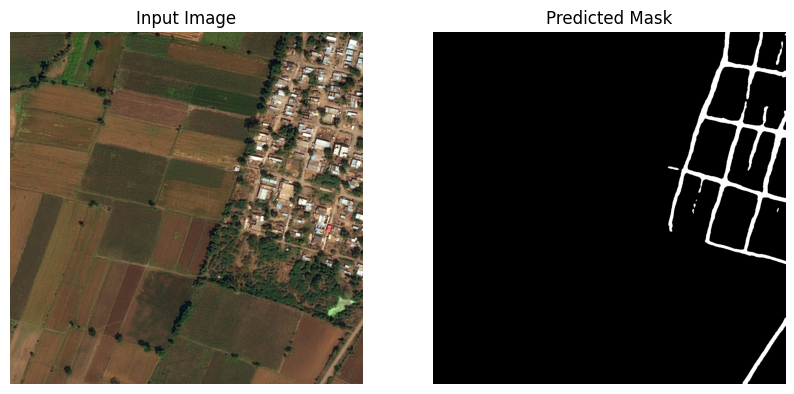

In [184]:
import matplotlib.pyplot as plt

img, mask = predict_image(model, os.path.join(valid_path, os.listdir(valid_path)[500]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

In [186]:
best_iou = 0

if val_metrics["iou"] > best_iou:
    best_iou = val_metrics["iou"]
    torch.save(model.state_dict(), "best_model.pth")

In [15]:
from torch.utils.data import DataLoader

train_dataset = RoadDataset(
    train_pairs,
    transform=train_transform
)

val_dataset = RoadDataset(
    val_pairs,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

In [16]:
model.load_state_dict(
    torch.load("best_model.pth")
)
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

In [ ]:
# unet with data augmentation trained for further 15 epochs

best_iou = 0.5715  # your previous best

num_epochs = 15

for epoch in range(num_epochs):

    model.train()

    train_loss = 0
    train_iou = 0
    train_dice = 0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for imgs, masks in loop:

        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        if torch.isnan(loss):
            print("NaN detected, skipping batch")
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        with torch.no_grad():
            iou = iou_score(preds, masks)
            dice = dice_score(preds, masks)

        train_loss += loss.item()
        train_iou += iou.item()
        train_dice += dice.item()

        n_batches += 1
        loop.set_postfix(loss=loss.item())

    # avoid crash if empty
    n_batches = max(n_batches, 1)

    train_metrics = {
        "loss": train_loss / n_batches,
        "iou": train_iou / n_batches,
        "dice": train_dice / n_batches,
    }

    val_metrics = evaluate(model, val_loader)

    print(f"""
Epoch {epoch+1}
Train Loss: {train_metrics['loss']:.4f} | IoU: {train_metrics['iou']:.4f} | Dice: {train_metrics['dice']:.4f}
Val   Loss: {val_metrics['loss']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f}
""")

    # save best model
    if val_metrics["iou"] > best_iou:
        best_iou = val_metrics["iou"]

        torch.save(model.state_dict(), "best_model_aug.pth")

        print(f"Saved new best model: IoU={best_iou:.4f}")

Epoch 1: 100%|██████████| 1245/1245 [04:13<00:00,  4.91it/s, loss=0.634]



Epoch 1
Train Loss: 0.4635 | IoU: 0.5070 | Dice: 0.6511
Val   Loss: 0.3425 | IoU: 0.6005 | Dice: 0.7481

Saved new best model: IoU=0.6005


Epoch 2: 100%|██████████| 1245/1245 [04:03<00:00,  5.12it/s, loss=0.415]



Epoch 2
Train Loss: 0.4497 | IoU: 0.5137 | Dice: 0.6624
Val   Loss: 0.3472 | IoU: 0.5980 | Dice: 0.7462



Epoch 3: 100%|██████████| 1245/1245 [04:03<00:00,  5.11it/s, loss=0.747]


...


Epoch 13
Train Loss: 0.4282 | IoU: 0.5330 | Dice: 0.6802
Val   Loss: 0.3422 | IoU: 0.5989 | Dice: 0.7466



Epoch 14: 100%|██████████| 1245/1245 [03:56<00:00,  5.27it/s, loss=0.279]



Epoch 14
Train Loss: 0.4313 | IoU: 0.5300 | Dice: 0.6716
Val   Loss: 0.3317 | IoU: 0.6121 | Dice: 0.7574

Saved new best model: IoU=0.6121


Epoch 15: 100%|██████████| 1245/1245 [03:57<00:00,  5.24it/s, loss=0.158] 



Epoch 15
Train Loss: 0.4153 | IoU: 0.5442 | Dice: 0.6894
Val   Loss: 0.3394 | IoU: 0.6057 | Dice: 0.7522



In [ ]:
# training loop deeplab v3
num_epochs = 30

scaler = torch.amp.GradScaler('cuda')

for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0
    train_iou = 0.0
    train_dice = 0.0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for imgs, masks in loop:

        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # with torch.amp.autocast('cuda'):

        preds = model(imgs)
        loss = loss_fn(preds, masks)

        # ---- safety check (IMPORTANT) ----
        if torch.isnan(loss):
            print(f"NaN loss detected at batch {n_batches}")
            break

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        # ---- metrics (detach + float-safe) ----
        with torch.no_grad():
            iou = iou_score(preds, masks)
            dice = dice_score(preds, masks)

        train_loss += loss.item()
        train_iou += iou.item()
        train_dice += dice.item()

        n_batches += 1

        loop.set_postfix(loss=loss.item())

    # ---- avoid division by zero ----
    n_batches = max(n_batches, 1)

    train_metrics = {
        "loss": train_loss / n_batches,
        "iou": train_iou / n_batches,
        "dice": train_dice / n_batches,
    }

    val_metrics = evaluate(model, val_loader)

    print(f"""
Epoch {epoch+1}
Train Loss: {train_metrics['loss']:.4f} | IoU: {train_metrics['iou']:.4f} | Dice: {train_metrics['dice']:.4f}
Val   Loss: {val_metrics['loss']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f}
""")

Epoch 1: 100%|██████████| 1245/1245 [04:13<00:00,  4.91it/s, loss=0.733]



Epoch 1
Train Loss: 1.1007 | IoU: 0.2862 | Dice: 0.4255
Val   Loss: 0.9833 | IoU: 0.3869 | Dice: 0.5551



Epoch 2: 100%|██████████| 1245/1245 [04:12<00:00,  4.94it/s, loss=0.602]



Epoch 2
Train Loss: 0.8212 | IoU: 0.3773 | Dice: 0.5306
Val   Loss: 0.7806 | IoU: 0.4240 | Dice: 0.5918



Epoch 3: 100%|██████████| 1245/1245 [04:02<00:00,  5.13it/s, loss=0.629]


...

Epoch 20: 100%|██████████| 1245/1245 [04:01<00:00,  5.16it/s, loss=0.448]



Epoch 20
Train Loss: 0.4572 | IoU: 0.5123 | Dice: 0.6585
Val   Loss: 0.8283 | IoU: 0.3539 | Dice: 0.5077



Epoch 21: 100%|██████████| 1245/1245 [04:01<00:00,  5.15it/s, loss=0.512]



Epoch 21
Train Loss: 0.4585 | IoU: 0.5111 | Dice: 0.6547
Val   Loss: 0.7673 | IoU: 0.3652 | Dice: 0.5189



Epoch 22:  24%|██▎       | 295/1245 [00:57<03:08,  5.03it/s, loss=0.168] 

In [18]:
model.load_state_dict(torch.load("best_model_aug.pth", map_location=device))
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [19]:
def predict_image(model, image_path):
    model.eval()

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (1024, 1024))

    x = torch.from_numpy(img_resized).float() / 255.0
    x = x.permute(2,0,1).unsqueeze(0).cuda()

    with torch.no_grad():
        pred = torch.sigmoid(model(x))[0,0].cpu().numpy()

    mask = (pred > 0.3).astype(np.float16)

    return img_resized, mask

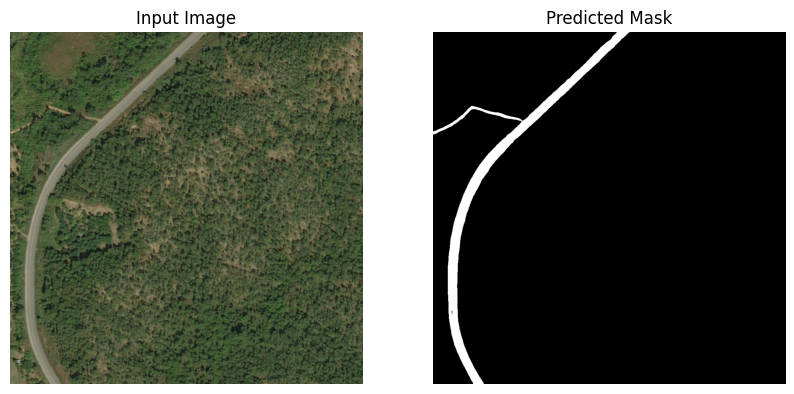

In [23]:
import matplotlib.pyplot as plt

img, mask = predict_image(model, os.path.join(valid_path, os.listdir(valid_path)[250]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()